In [1]:
# 02 - Data Cleaning
# Flow: standardize category names -> handle conditional (skip-logic) missing
#       values -> remove/avoid identifiers from ML -> convert multi-select
#       answers -> prepare categorical variables

import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

RAW_DATA_PATH = "data/raw/AI_Tool_Usage_and_Adoption_Survey__Responses_.xlsx"
df = pd.read_excel(RAW_DATA_PATH)
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")


Loaded: 200 rows x 20 columns


In [2]:
# Rename columns to concise, analysis-friendly names
rename_map = {
    'Timestamp': 'Timestamp',
    'Email Address': 'Email',
    'Enter your age group.': 'Age_Group',
    'What is your gender?': 'Gender',
    'What is your current occupation?': 'Occupation',
    'Where do you primarily live?': 'Residence_Type',
    'Enter your Home Address.': 'Home_Address',
    'Do you currently use any AI tools (e.g., ChatGPT, Claude, Gemini, Copilot)?': 'Uses_AI_Tools',
    'Which AI tools do you use or are familiar with? (Select all that apply)': 'AI_Tools_Known',
    'Select how often you use AI tools.': 'Usage_Frequency',
    'What do you mainly use AI tools for?': 'Usage_Context',
    'What is the main purpose of using AI tools?': 'Usage_Purpose',
    'Which AI tool do you use most frequently?': 'Most_Used_Tool',
    'Rate your satisfaction with your most-used AI tool.': 'Satisfaction',
    'Why do you prefer your most-used AI tool over others? (Select one)': 'Preference_Reason',
    'What are your main concerns about using AI tools?': 'Concerns',
    ' Select the biggest reason you would switch to a different AI tool.': 'Switch_Reason',
    'Select the main reason you do not use AI tools.': 'NonUse_Reason',
    'Would you consider using an AI tool in the future?': 'Future_Consideration',
    'Enter any additional comments or suggestions regarding AI tools.': 'Comments',
}
df = df.rename(columns=rename_map)
df.columns.tolist()


['Timestamp',
 'Email',
 'Age_Group',
 'Gender',
 'Occupation',
 'Residence_Type',
 'Home_Address',
 'Uses_AI_Tools',
 'AI_Tools_Known',
 'Usage_Frequency',
 'Usage_Context',
 'Usage_Purpose',
 'Most_Used_Tool',
 'Satisfaction',
 'Preference_Reason',
 'Concerns',
 'Switch_Reason',
 'NonUse_Reason',
 'Future_Consideration',
 'Comments']

In [3]:
#  Remove identifiers / PII (never feed these to ML) 
df = df.drop(columns=[c for c in ['Email', 'Home_Address'] if c in df.columns])
print("Dropped: Email, Home_Address")
print("Remaining columns:", len(df.columns))


Dropped: Email, Home_Address
Remaining columns: 18


In [4]:
# --- Normalize timestamp to a date, trim whitespace ---
df['Timestamp'] = pd.to_datetime(df['Timestamp']).dt.strftime('%Y-%m-%d')
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan})
print("Done")


Done


/tmp/ipykernel_736/2232716412.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


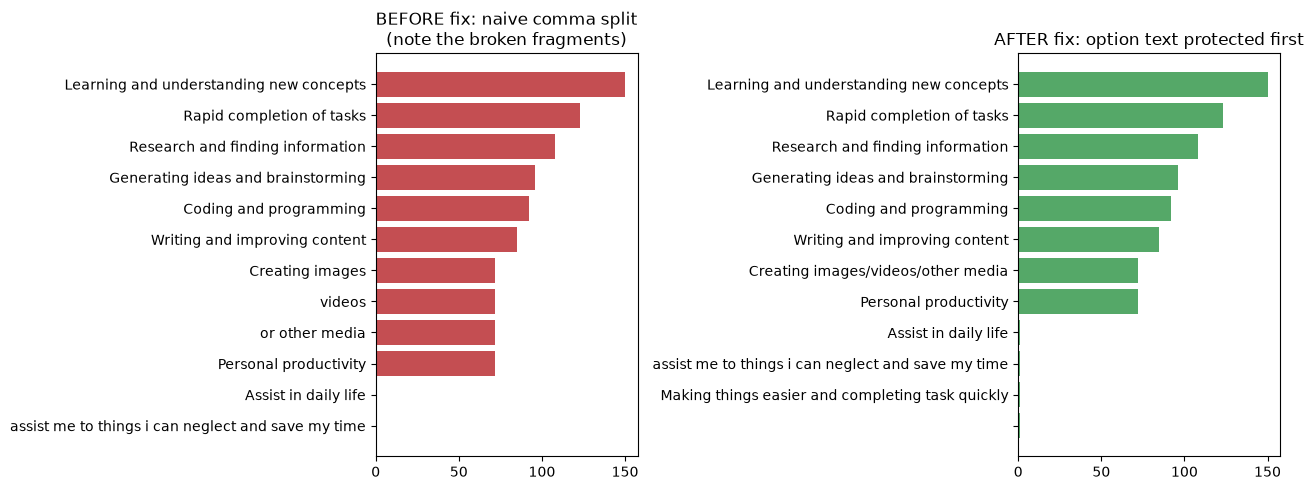

In [4]:
#  Bug check: multi-select checkbox option containing its own commas 
# "Creating images, videos, or other media" is ONE checkbox option, but it has
# commas inside its own text. The raw export joins multi-select answers with
# commas, so naive splitting shreds this single option into 3 fake answers for
# every respondent who selected it (72 of them). Show the broken split first,
# then show the fixed one, as a before/after diagram.
purpose_col = 'Usage_Purpose'
naive_split = df[purpose_col].dropna().str.split(', ').explode().str.strip()
naive_counts = naive_split.value_counts().head(12)

# apply the fix: protect the option's internal commas before splitting
df[purpose_col] = df[purpose_col].str.replace(
    'Creating images, videos, or other media', 'Creating images/videos/other media', regex=False
)
# one respondent's free-text "Other" write-in also had commas -- repair as one entry
long_writein = (
    "Well yes the above option are all the purposes of ai through the pov of most people but "
    "actually ai was mostly made for simplification of human work so mostly its purpose shall "
    "be the creation, replacement , and improvement of things humans made"
)
mask = df[purpose_col].str.contains('pov of most people', na=False)
df.loc[mask, purpose_col] = df.loc[mask, purpose_col].str.replace(
    long_writein,
    'Other: AI mainly for simplification, creation, replacement, and improvement of human tasks',
    regex=False
)
fixed_split = df[purpose_col].dropna().str.split(', ').explode().str.strip()
fixed_counts = fixed_split.value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(naive_counts.index[::-1], naive_counts.values[::-1], color='#C44E52')
axes[0].set_title('BEFORE fix: naive comma split\n(note the broken fragments)')
axes[1].barh(fixed_counts.index[::-1], fixed_counts.values[::-1], color='#55A868')
axes[1].set_title('AFTER fix: option text protected first')
plt.tight_layout()
plt.show()


In [5]:
#  Convert multi-select answers (comma -> semicolon separated)
multi_cols = ['AI_Tools_Known', 'Usage_Context', 'Usage_Purpose', 'Concerns']
for c in multi_cols:
    df[c] = df[c].str.replace(r',\s*', '; ', regex=True)
df[multi_cols].head(3)


,AI_Tools_Known,Usage_Context,Usage_Purpose,Concerns
0,ChatGPT; Claude; Gemini,Study / Academic work,Rapid completion of tasks; Learning and unders...,Data privacy and security; Accuracy and reliab...
1,ChatGPT; Claude; Gemini,Study / Academic work; Coding / Technical work...,Rapid completion of tasks; Learning and unders...,Data privacy and security; Accuracy and reliab...
2,ChatGPT; Claude; Gemini; Copilot; DeepSeek,Study / Academic work; Content creation / Writ...,Rapid completion of tasks; Learning and unders...,Cost of premium features


In [6]:
# Standardize category names: AI tool names (casing / duplicates)
tool_name_map = {
    'grock': 'Grok', 'grox': 'Grok', 'grok': 'Grok',
    'opencode': 'OpenCode',
    'perplexity': 'Perplexity',
    'blackbox': 'Blackbox',
    'kimi ai': 'Kimi AI',
    'meta ai etc': 'Meta AI',
    'qwek': 'Qwen',
    'z.ai': 'Z.ai',
    'notebooklm.com': 'NotebookLM',
}
def fix_tools(cell):
    if pd.isna(cell):
        return cell
    parts = [p.strip() for p in cell.split(';') if p.strip()]
    fixed = [tool_name_map.get(p.lower(), p) for p in parts]
    seen, out = set(), []
    for p in fixed:
        if p not in seen:
            seen.add(p); out.append(p)
    return '; '.join(out)

df['AI_Tools_Known'] = df['AI_Tools_Known'].apply(fix_tools)
df['AI_Tools_Known'].head()


0                       ChatGPT; Claude; Gemini
1                       ChatGPT; Claude; Gemini
2    ChatGPT; Claude; Gemini; Copilot; DeepSeek
3              ChatGPT; Claude; Gemini; Copilot
4                               ChatGPT; Gemini
Name: AI_Tools_Known, dtype: str

In [7]:
#  Standardize category names: Occupation 
occ_map = {
    'Berojgar': 'Unemployed',
    'dental surgen': 'Dental Surgeon',
    'Engineering': 'Engineer',
    'Ophthalmic assistant': 'Ophthalmic Assistant',
    'Student plus working professional': 'Student & Working Professional',
    'Social work': 'Social Worker',
}
df['Occupation'] = df['Occupation'].replace(occ_map)
df['Occupation'].value_counts()


Occupation
Student                           135
IT professional                    24
Private-sector Employee            12
Teacher                            10
Business owner                      4
Government Employee                 4
Researcher                          2
Unemployed                          1
Ophthalmic assistant                1
Engineering                         1
Unemployed                          1
Student & Working Professional      1
Dental Surgeon                      1
Freelancer                          1
Doctor                              1
Social work                         1
Name: count, dtype: int64

In [8]:
#  Handle conditional (skip-logic) missing values 
# Respondents who don't use AI tools correctly leave AI-usage questions blank,
# and vice versa. We keep these as real missing values (not imputed) and add
# a helper flag so downstream analysis/ML code can filter cleanly.
df['Is_AI_User'] = (df['Uses_AI_Tools'] == 'Yes')
print(df['Is_AI_User'].value_counts())

usage_only_cols = ['Most_Used_Tool', 'Satisfaction', 'Preference_Reason',
                    'Usage_Frequency', 'Usage_Context', 'Usage_Purpose', 'Concerns', 'Switch_Reason']
print()
print("Missing values in usage-only columns, split by Is_AI_User:")
print(df.groupby('Is_AI_User')[usage_only_cols].apply(lambda g: g.isna().sum()))


Is_AI_User
True     195
False      5
Name: count, dtype: int64

Missing values in usage-only columns, split by Is_AI_User:
            Most_Used_Tool  Satisfaction  Preference_Reason  Usage_Frequency  \
Is_AI_User                                                                     
False                    5             5                  5                5   
True                     0             0                  0                0   

            Usage_Context  Usage_Purpose  Concerns  Switch_Reason  
Is_AI_User                                                         
False                   5              5         5              5  
True                    0              0         0              0  


In [10]:
def redact_phone(val):
    if pd.isna(val):
        return val
    val = str(val).strip()
    if re.fullmatch(r'\d{7,}', val):
        return '[REMOVED - PII]'
    return val

df['Comments'] = df['Comments'].apply(redact_phone)

null_equivalents = {
    'no', 'no.', 'none', 'none.', 'none for now', 'nothing', 'nothing.',
    'nothing much', 'n/a', 'na', 'nil', 'ntg', 'ntg in mind rn', 'nope',
    'nah', 'no comment', 'no comments', 'no suggestions', 'no for now',
    'no thank you', 'no, thank you', '.', '..', '...', '....', '.....',
    '-', '—', '———',
    "i don't have additional comment. wondering why this is mandatory field.",
    "i don't have any additional comments and suggestions regarding ai tools",
    "i have no additional comments."
}

def is_null_equivalent(val):
    if pd.isna(val):
        return True
    val = str(val).strip().lower()
    normalized = val.rstrip('.').strip()
    return val in null_equivalents or normalized in null_equivalents

df['Has_Comment'] = df['Comments'].apply(
    lambda v: 'No' if is_null_equivalent(v) or v == '[REMOVED - PII]' else 'Yes'
)

df.loc[
    (df['Has_Comment'] == 'No') &
    (df['Comments'] != '[REMOVED - PII]'),
    'Comments'
] = pd.NA

print(df['Has_Comment'].value_counts())

Has_Comment
Yes    119
No      81
Name: count, dtype: int64


In [11]:
def classify_theme(text):
    if pd.isna(text) or text == '[REMOVED - PII]':
        return np.nan
    t = text.lower()
    if re.search(r'\bsurvey\b|\bhome address\b|mandatory field|\bqn\b|targeted survey|questions may not|well designed', t):
        return 'Survey/Research Feedback'
    if re.search(r'privacy|leak|security|permission|data (protection|governance|custody|isolation)|confidential', t):
        return 'Privacy & Data Security'
    if re.search(r'\bfree\b|premium|subscription|afford|budget|cheap|expensive|\bcost\b|\bpro version\b|caheya|lower the cost', t):
        return 'Pricing & Affordability'
    if re.search(r'accura|hallucinat|reliab|incorrect|wrong info|verify|fact.?check|up-to-date', t):
        return 'Accuracy & Reliability'
    if re.search(r'depend|replace human|lazy|creativity|ethic|degrees|job|autonomy|brain|slop|below 16|children', t):
        return 'Ethics, Dependence & Societal Impact'
    if re.search(r'simple language|user.?friendly|easy to use|feature|context|memory|video chat|voice|nepali|transparen|adapt|industry|role|token|arena', t):
        return 'Usability & Feature Suggestions'
    if re.search(r'helpful|love|enjoy|satisf|thank|\bnice\b|good luck|wonderful|game.?changer|useful|great|easy to get|easy to study|maximize|efficiency|helping hand', t):
        return 'Positive Experience'
    if re.search(r'nai xaina|caheya hamko|lai nai sodeko|^banana$', t):
        return 'Non-English / Unclear'
    return 'Other / General Remark'

df['Feedback_Theme'] = df['Comments'].apply(classify_theme)
df['Feedback_Theme'].value_counts(dropna=False)


Feedback_Theme
NaN                                     81
Other / General Remark                  37
Pricing & Affordability                 18
Positive Experience                     17
Ethics, Dependence & Societal Impact    12
Privacy & Data Security                 12
Accuracy & Reliability                  10
Usability & Feature Suggestions          8
Survey/Research Feedback                 4
Non-English / Unclear                    1
Name: count, dtype: int64

In [12]:
# Prepare categorical variables: ordinal codes 
# These numeric codes make ordered categories (Age_Group, Usage_Frequency,
# Satisfaction usable in correlation tests and ML models, while the original
# text columns stay for readable charts and tables.
age_order = {'13 - 17': 1, '18 - 24': 2, '25 - 34': 3, '35 - 44': 4, '45 and above': 5}
freq_order = {
    'Once a month': 1, 'Several times a month': 2, 'Once a week': 3,
    'Several times a week': 4, 'Once a day': 5, 'Several times a day': 6
}
sat_order = {'Very Dissatisfied': 1, 'Dissatisfied': 2, 'Neutral': 3, 'Satisfied': 4, 'Very Satisfied': 5}

df['Age_Group_Code'] = df['Age_Group'].map(age_order)
df['Usage_Frequency_Code'] = df['Usage_Frequency'].map(freq_order)
df['Satisfaction_Code'] = df['Satisfaction'].map(sat_order)
df['Uses_AI_Tools_Bin'] = df['Uses_AI_Tools'].map({'Yes': 1, 'No': 0})

df.insert(0, 'Respondent_ID', ['R' + str(i + 1).zfill(3) for i in range(len(df))])
cols = df.columns.tolist()
cols.remove('Timestamp')
cols.insert(1, 'Timestamp')
df = df[cols]
df.head(3)


,Respondent_ID,Timestamp,Age_Group,Gender,Occupation,Residence_Type,Uses_AI_Tools,AI_Tools_Known,Usage_Frequency,Usage_Context,Usage_Purpose,Most_Used_Tool,Satisfaction,Preference_Reason,Concerns,Switch_Reason,NonUse_Reason,Future_Consideration,Comments,Is_AI_User,Has_Comment,Feedback_Theme,Age_Group_Code,Usage_Frequency_Code,Satisfaction_Code,Uses_AI_Tools_Bin
0,R001,2026-09-15 15:42:29.032,18 - 24,Female,Student,Semi - Urban,Yes,ChatGPT; Claude; Gemini,Several times a day,Study / Academic work,Rapid completion of tasks; Learning and unders...,Claude,Satisfied,Better performance for my specific purpose,Data privacy and security; Accuracy and reliab...,No Plan to Switch,NaN,NaN,IAM fine using AI tool,True,Yes,Other / General Remark,2,6.0,4.0,1
1,R002,2026-09-15 15:48:37.254,18 - 24,Female,Student,Urban,Yes,ChatGPT; Claude; Gemini,Several times a day,Study / Academic work; Coding / Technical work...,Rapid completion of tasks; Learning and unders...,ChatGPT,Satisfied,Ease of use,Data privacy and security; Accuracy and reliab...,Better Accuracy,NaN,NaN,Satisfied with currently using AI Tools.,True,Yes,Positive Experience,2,6.0,4.0,1
2,R003,2026-09-15 16:15:37.488,18 - 24,Male,Student,Urban,Yes,ChatGPT; Claude; Gemini; Copilot; DeepSeek,Several times a day,Study / Academic work; Content creation / Writ...,Rapid completion of tasks; Learning and unders...,Claude,Very Satisfied,Better performance for my specific purpose,Cost of premium features,Lower Cost,NaN,NaN,NaN,True,No,NaN,2,6.0,5.0,1


In [13]:
#  Final checks
print(f"Final shape: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print("Remaining missing values (expected -- survey skip-logic):")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Note for the ML stage (05 onward): Respondent_ID, Timestamp, Comments, and
# Feedback_Theme are NOT used as ML predictors, kept only for reference.


Final shape: (200, 26)
Duplicate rows: 0

Remaining missing values (expected -- survey skip-logic):
AI_Tools_Known            5
Usage_Frequency           5
Usage_Context             5
Usage_Purpose             5
Most_Used_Tool            5
Satisfaction              5
Preference_Reason         5
Concerns                  5
Switch_Reason             5
NonUse_Reason           195
Future_Consideration    195
Comments                 80
Feedback_Theme           81
Usage_Frequency_Code      6
Satisfaction_Code         5
dtype: int64


In [14]:
#  Save cleaned dataset 
os.makedirs('data/processed', exist_ok=True)
out_csv = 'data/processed/AI_Tool_Survey_Cleaned.csv'
out_xlsx = 'data/processed/AI_Tool_Survey_Cleaned.xlsx'
df.to_csv(out_csv, index=False)
df.to_excel(out_xlsx, index=False, sheet_name='Cleaned_Data')
print(f"Saved: {out_csv}")
print(f"Saved: {out_xlsx}")


Saved: data/processed/AI_Tool_Survey_Cleaned.csv
Saved: data/processed/AI_Tool_Survey_Cleaned.xlsx
